In [1]:
%cd "C:/Users/20251553/OneDrive - TU Eindhoven/Documents/Jupyter projects/Year-2"

C:\Users\20251553\OneDrive - TU Eindhoven\Documents\Jupyter projects\Year-2


# Streamer analysis — control center (V3)

A Python replacement for the parts of **Streamertools** (S. Nijdam, TU/e,
manual of 31 March 2022) that this project needs, plus streamer-velocity
measurements the original suite does not have. Every function and class lives
in `streamertools/`; this notebook only drives them. V1 and V2 are kept
alongside this file.

## What V3 does differently from V2

**1 · Two permanent windows instead of pop-ups.** The **velocity window**
(section 3a) and the **thickness window** (section 3b) each stay open for the
whole session, next to the notebook, and are never merged. The notebook stays
on `%matplotlib inline`, so result figures keep appearing under their cells.
Zooming, panning and cropping happen in the windows.

**2 · One cell per window.** Edit a window's cell and re-run *only that cell*:
the window updates in place, or reopens if you closed it. Settings are applied
on every run; what the window changes itself (series, frame, crop, tool) only
when you changed it in the cell.

**3 · A list of series, worked through in the window.** `SERIES` (section 1)
lists the files. Each window has three buttons:

| button | does |
|---|---|
| **Save mean velocity** / **Save mean thickness** | one row per series in `velocity_summary.csv` / `thickness_summary.csv` (saving again replaces the row) |
| **Next series >** | moves on; asks first if this series changed since its mean was saved |
| **Save and close** | saves the series shown and closes the window, at any time |

Every click is also written to a per-series CSV at once and restored when the
series is opened again.

**4 · Heads located by hand, frame by frame.** With the velocity window's
*head* tool, click the head in frame 17; the window moves to 18, click, 19 …
and the frame-to-frame velocity is recomputed after every click.

**5 · The automatic head is the literature's.** The head of the streamer
that protruded furthest, located where its axial profile falls to half
maximum; the velocity is the slope of head position against end-of-exposure
time (Briels *et al* 2008, Winands *et al* 2008, Nijdam 2011) — section 5.

**6 · Single-frame or multi-frame files, and every file type of the manual.**
`FILE_MODE` (section 1) switches between a series stored as *one
multi-frame file* (`"multi"`, e.g. a kinetic `.sif`) and a series stored as
*one file per delay* (`"single"`, e.g. a folder of `.img` shots — the
Briels/Winands way). Every file type of manual §2.1 can be read: Stanford
`.img`/`.rtv`, Princeton `.spe`, Andor `.sif`, SBIG `.st2k`, CWI `.tsv`,
FITS, Photron `.cih`/`.raw`, Shimadzu `.dat`, LaVision `.im7`, the
Streamertools `.txt`/`.streamer`, `.avi`, and `.jpg`/`.png`/`.bmp`/`.tif`.
For single-frame files the dark subtraction is a switch, `SUBTRACT_DARK`:
on subtracts the dark shot(s) in `DARK_PATH`, off subtracts nothing.

`PIXEL_SIZE_UM = None` still means *work in pixels*: widths in px, velocities
in px/ns, both with error bars.

## 0 · Setup

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# the streamertools package sits next to this notebook
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamertools as st
from streamertools import plotting as stplot

print("streamertools", st.__version__)     # expect 1.10.0
# If an import looks stale:  %run check_install.py

streamertools 1.10.0


## 1 · Data configuration

Which files, and how every one of them is loaded.

**`FILE_MODE` is the switch between the two ways a delay series is stored:**

| `FILE_MODE` | one entry of `SERIES` is | example |
|---|---|---|
| `"multi"` | one multi-frame file (a movie, a kinetic series) | `r"Imaging/raw/20260701/kinetic.sif"` |
| `"single"` | the single-frame files of one series, one per delay: a **folder**, a **glob pattern**, or a **list** of files | `r"Imaging/raw/20260917/run3"`, `r"Imaging/raw/20260917/run3/*.img"` |

In `"single"` mode the files are taken in name order, with numbers compared as
numbers (`shot2` before `shot10`); give a list to set the order yourself.
**Dark / background subtraction** — what is subtracted from every frame:

| `FILE_MODE` | |
|---|---|
| `"single"` | a switch. `SUBTRACT_DARK = True`: the dark in `DARK_PATH` — one file, or a folder, pattern or list of dark shots, averaged. `SUBTRACT_DARK = False`: nothing, the counts stay as recorded |
| `"multi"` | always: `DARK_PATH` if given, otherwise the mean of the first `DARK_FROM_FRAMES` frames, otherwise the median of the image corners |

`PREP` is used by the notebook and by both windows, so a series looks the same everywhere.

**`PIXEL_SIZE_UM` is the drop-in calibration result.** Leave it `None` to work
in pixels; set it to the number `calibrate.py` printed to work in physical
units. It is the only place the calibration enters the notebook.

In [3]:
# --- how a series is stored --------------------------------------------------
FILE_MODE = "single"       # "multi":  one multi-frame file per series
                          # "single": one file per frame -- a folder, pattern or list per series

# --- data: the series, worked through in this order -------------------------
SERIES = [
    r"Imaging/raw/20260619/four_streamers.sif",
    # r"Imaging/raw/20260907/perfect_100mbar_57cm_8cm_6stg_14kv.sif",
]
# FILE_MODE = "single" -- one entry per series, for example:
# SERIES = [
#     r"Imaging/raw/20260917/run1",                    # every image file in a folder
#     r"Imaging/raw/20260917/run2/shot_*.img",         # a glob pattern
#     [r"Imaging/raw/20260917/a.img", r"Imaging/raw/20260917/b.img"],   # an explicit list
# ]
ROT90_K    = 2               # quarter turns applied on load (2 = 180 deg)

# --- dark / background subtraction ------------------------------------------
# FILE_MODE = "single": switched on or off here.
SUBTRACT_DARK = False     # True:  subtract the dark in DARK_PATH from every frame
                          # False: subtract nothing (the counts as recorded)
# the dark/background: one file (its frames averaged), or a folder, pattern or
# list of dark shots (all averaged)
DARK_PATH  = None #r"Year-2/Imaging/raw/20260902/bgForMemory.sif"   # or None
# FILE_MODE = "multi": always subtracted -- DARK_PATH if given, otherwise the mean
# of the first DARK_FROM_FRAMES frames of each series, otherwise the image corners.
DARK_FROM_FRAMES = 2      # e.g. 3 -> mean of the first 3 frames of each series

# --- geometry: the calibration drop-in --------------------------------------
# Measured once per optical setup with calibrate.py; see calibration_log.csv.
#     None  -> widths in px, velocities in px/ns  (everything still works)
#     float -> widths in um, velocities in m/s
PIXEL_SIZE_UM = None          # e.g. 17.0 ; None -> work in pixels
PIXEL_SIZE_REL_ERROR = 0.02   # relative uncertainty on it, used in the error bars

# --- physical brightness normalisation (optional) --------------------------
APPLY_PHYSICAL_NORM = False  # divide by Mf so shots at different gain compare
Vg, D          = 800.0, 4.5  # gain voltage, f-number
CMAX, CMIN     = 5000.0, 100.0
NORM_FACTOR    = 500.0
Mf_REF         = 1.0         # keep identical across every shot you compare

# --- how every series is loaded: by the notebook and by both windows -------
PREP = dict(mode=FILE_MODE, rot90=ROT90_K, pixel_size_um=PIXEL_SIZE_UM,
            subtract_dark=SUBTRACT_DARK if FILE_MODE == "single" else True,
            dark_path=DARK_PATH, dark_from_frames=DARK_FROM_FRAMES,
            physical_norm=(dict(Vg=Vg, D=D, c_max=CMAX, c_min=CMIN,
                                norm_factor=NORM_FACTOR, Mf_ref=Mf_REF)
                           if APPLY_PHYSICAL_NORM else None))

# --- output -----------------------------------------------------------------
OUT_DIR = Path("Imaging/processed/streamer_analysis/20260701")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2 · Load  *(manual 2.1)*

`st.prepare_series` loads a series the way `PREP` says — one file, or in
`"single"` mode all the files of one series stacked in order — rotated, dark-subtracted
as section 1 says, and optionally normalised. The `dark:` line shows what was
subtracted; both windows show it in their title bar too. The windows load their series the same way, and a series still
held here is not loaded a second time.

In [4]:
stack = st.prepare_series(SERIES[0], **PREP)
print(stack.describe())
print("dark:", stack.metadata["dark"])
if FILE_MODE == "single":
    files = stack.metadata["sources"]
    print(f"{len(files)} files: {Path(files[0]).name} ... {Path(files[-1]).name}")
if stack.metadata.get("Mf"):
    print(f"Mf = {stack.metadata['Mf']:.4g}  (comparable to other shots sharing Mf_REF = {Mf_REF})")

single image  2160x2560  counts 37.0 -> 13188.0  (uncalibrated)
dark: off
1 files: four_streamers.sif ... four_streamers.sif


In [5]:
stack.show_metadata() #key_filter="gain"     # drop the filter to see every field

SifVersion           : 65567
ExperimentTime       : 1781878414
DetectorTemperature  : -999.0
ExposureTime         : 0.100008
CycleTime            : 0.110116
AccumulatedCycleTime : 0.110116
AccumulatedCycles    : 1
StackCycleTime       : 0.110116
PixelReadoutTime     : 1.78571e-09
GainDAC              : 0.0
GateWidth            : 1e-07
GratingBlaze         : 0.0
DetectorType         : iStar-sCMOS18UE3-S
DetectorDimensions   : <tuple n=2> [2560, 2160]
OriginalFilename     : b'S:\\Information_on_Name\\AyushK\\images\\19_06_26_botl\\four_streamers.sif'
ShutterTime          : <tuple n=2> [0., 0.]
spectrograph         : Spectrograph_None999
GateGain             : 2500.0
GateDelay            : 3e-07
SifCalbVersion       : 65540
Calibration_data     : <list n=4> [0., 1., 0., 0.]
RamanExWavelength    : 422.0
FrameAxis            : b'Pixel number'
DataType             : b'Counts'
ImageAxis            : b'Pixel number'
NumberOfFrames       : 1
NumberOfSubImages    : 1
TotalLength          : 55296

## 3 · The two windows

**Each window has its own cell below; re-run that cell to change it.** The
first run opens the window, later runs update it, and a closed window comes
back with everything you did in it.

| in both windows | |
|---|---|
| series list, **Save mean …**, **Next series >**, **Save and close** | work through `SERIES` (Ctrl+S saves the mean) |
| ← → (or `,` `.`), Home / End, slider, spin box | step through the frames |
| mouse wheel · middle-drag · toolbar | zoom · pan · zoom rectangle, *home*, save a picture |
| tool **view** (`v`) | just look |
| tool **crop** (`c`) | drag a rectangle to crop to it; *Crop to view* crops to the current zoom; *Full frame* undoes it |

| velocity window only | |
|---|---|
| tool **head** (`h`) | click the head, and the window moves on; right-click or Delete removes it |
| `d`, *Detect this frame*, *Detect from here* | place heads automatically (the literature front) for you to correct |

| thickness window only | |
|---|---|
| tool **line** (`l`) | click both ends of a straight channel section: the diameter is measured at once; right-click cancels or removes the selected line |
| `d`, *Detect channel* | a line along the largest channel of the frame |
| click a row of the table | select that line and show its frame |

Coordinates in a window are those of its **cropped** series, `vwin.work` /
`twin.work`. The *CROP* field shows the line to paste back into the cell.

The windows run on the kernel's Qt event loop. While a cell is running they do
not respond, and they come back when the cell finishes. Any `%matplotlib …`
magic, including re-running the setup cell, unhooks that loop; re-run a
window cell and both windows are live again.

### 3a · The velocity window

In [6]:
# ---- how counts are drawn (also used by the inline figures below) -------------
DISPLAY = st.DisplaySettings(gamma=1.0, palette="inferno", limit_mode="histogram",
                             min_hist_percentage=1.0, max_hist_percentage=99.8,
                             scope="global")   # "global": one scale for the whole series

# ---- where to look  (applied when you change them here) ----------------------
START_SERIES = 0           # index in SERIES
FRAME = 39                 # first frame shown in every series (20260701: the head appears at 39)
CROP  = {"x0": 153, "x1": 312, "y0": 20, "y1": 250}   # as cropped in the window on 20260701; None = full frame
TOOL  = "head"             # "view" | "crop" | "head"
AUTO_ADVANCE = True        # head tool: go to the next frame after each click

# ---- timing, direction, uncertainty ------------------------------------------
DELAY_NS        = 10.0     # gate-delay step between frames
GATE_NS         = 10.0     # exposure (20260701: 10 ns gate); a head is where it was at its END
TIMES_NS        = None     # or np.array([...]): the measured gate delay of every frame
DELAY_JITTER_NS = 0.5      # trigger jitter, folded into the error bars
AXIS            = "down"   # propagation direction, or (dx, dy); None -> from the track
ORIGIN          = None     # (x, y) of the electrode tip in window coordinates, if known
CLICK_UNCERTAINTY_PX = 1.5 # how well a head is placed by eye
BRIDGE_GAPS     = False    # True: a skipped frame pairs its neighbours over 2 x dt

# ---- the automatic head (Detect buttons, and section 5) ----------------------
# method="front": the half-maximum edge of the furthest-protruding streamer.
# min_peak: a frame counts as holding a streamer only above this many counts.
# Shot dependent: on 20260907 empty frames peak below ~25, the streamer above ~150;
# on 20260701 the propagating streamer peaks at 15000-33000 counts.
# These are counts after the dark: with SUBTRACT_DARK off the camera offset adds in.
HEAD_DETECT = st.HeadSettings(method="front", front_level=0.5,
                              threshold=0.35, threshold_mode="fraction_of_max",
                              smooth_sigma=1.0, min_component_size=20,
                              min_peak=50.0)

vwin = st.open_velocity_window(
    SERIES, prepare=PREP, out_dir=OUT_DIR, display=DISPLAY,
    series_index=START_SERIES, frame=FRAME, crop=CROP, tool=TOOL,
    auto_advance=AUTO_ADVANCE,
    delay_ns=DELAY_NS, gate_ns=GATE_NS, times_ns=TIMES_NS,
    delay_jitter_ns=DELAY_JITTER_NS, pixel_size_rel_error=PIXEL_SIZE_REL_ERROR,
    axis=AXIS, origin=ORIGIN, click_uncertainty_px=CLICK_UNCERTAINTY_PX,
    bridge_gaps=BRIDGE_GAPS, head_settings=HEAD_DETECT)
vwin

<VelocityWorkbench series 1/1 'four_streamers.sif', frame 0/0, 159x230 px, {'x0': 153, 'x1': 312, 'y0': 20, 'y1': 250}, tool 'head', 0 series saved, window open>

In [9]:
# the velocity window's state, for sections 4 and 5 -- re-run after moving on there
work = vwin.work             # the series shown, cropped as in the window (a view)
frame_index = vwin.frame     # the frame the window shows
SHOT = vwin.series_stem      # names this series' output files
print(vwin)
print(f"CROP = {vwin.crop}")
units = "um and m/s (shown as mm/ns)" if work.pixel_size_um else "px and px/ns"
print(f"PIXEL_SIZE_UM = {work.pixel_size_um!r}  ->  results in {units}")

<VelocityWorkbench series 1/1 '10nsgate_10acc_kinetic_70mbar_600nswidth_9kv.sif', frame 42/59, 159x230 px, {'x0': 153, 'x1': 312, 'y0': 20, 'y1': 250}, tool 'head', 0 series saved, window open>
CROP = {'x0': 153, 'x1': 312, 'y0': 20, 'y1': 250}
PIXEL_SIZE_UM = None  ->  results in px and px/ns


### 3b · The thickness window

A separate window with its own cell, its own crop and its own files. The
diameter is the FWHM of the cross sections averaged along a straight channel
section (Briels *et al* 2008; Nijdam 2011, §3.4.3); Nijdam asks for at least
10 px across, and narrower lines are flagged. Place a line on every suitable
section — Briels evaluates three to ten streamers per image, over several
images — and *Save mean thickness* averages them all.

In [9]:
# ---- how counts are drawn ----------------------------------------------------
T_DISPLAY = st.DisplaySettings(gamma=1.0, palette="inferno", limit_mode="histogram",
                               min_hist_percentage=1.0, max_hist_percentage=99.8,
                               scope="global")

# ---- where to look  (applied when you change them here) ----------------------
T_START_SERIES = 0
T_FRAME = 45               # 20260701: mid-propagation
T_CROP  = {"x0": 153, "x1": 312, "y0": 20, "y1": 250}   # as cropped in the window on 20260701; None = full frame
T_TOOL  = "line"           # "view" | "crop" | "line"
T_DELAY_NS = 10.0          # only for the delay shown in the window

# ---- the measurement ---------------------------------------------------------
BOX_W = 75                 # box across the line, about 5x the expected diameter
AVERAGING_NUMBER = 8       # X of the moving average (manual 3.2), per-line numbers
MIN_DIAMETER_PX = 10       # Nijdam (2011): narrower is not measured reliably

twin = st.open_thickness_window(
    SERIES, prepare=PREP, out_dir=OUT_DIR, display=T_DISPLAY,
    series_index=T_START_SERIES, frame=T_FRAME, crop=T_CROP, tool=T_TOOL,
    delay_ns=T_DELAY_NS, box_width=BOX_W, averaging_number=AVERAGING_NUMBER,
    min_diameter_px=MIN_DIAMETER_PX)
twin

thickness window: kept its own frame=0, crop=None -- unchanged in this cell since it last ran. goto(...), goto_series(...), set_crop(...) or configure(..., force=True) override it.


<ThicknessWorkbench series 1/1 'four_streamers.sif', frame 0/0, 2560x2160 px, full frame, tool 'line', 0 series saved, window open>

### Colours and gamma, inline  *(manual 2.2)*

Counts become colours in two steps that are kept strictly apart:

1. **counts → [0, 1]** with $I_{out} = \left(\frac{I_{in}-I_{min}}{I_{max}-I_{min}}\right)^{1/\gamma}$,
   or, for $\gamma \geq 10$, $I_{out} = \log_{10}\!\left(1 + 9\frac{I_{in}-I_{min}}{I_{max}-I_{min}}\right)$
2. **[0, 1] → RGB** through a palette (a `*.pal` file, or any matplotlib colormap)

The percentiles only *choose* $I_{min}$/$I_{max}$, and the exponent follows the
manual's $1/\gamma$ convention, so "gamma 1.5" means the same here as in
Streamertools. Pick a value below, then set it in a window cell.

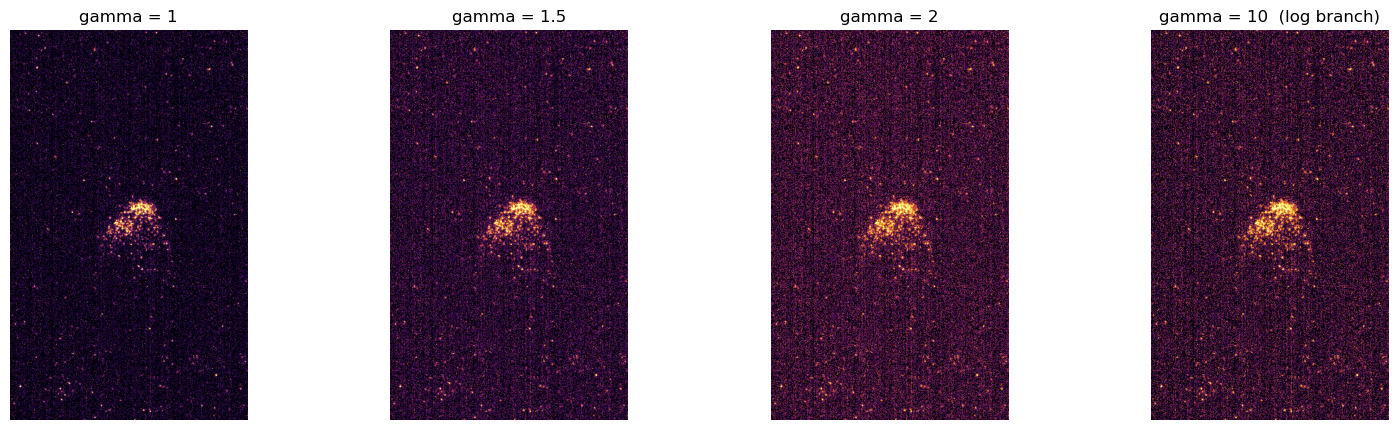

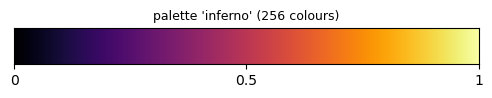

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, g in zip(axs, [1.0, 1.5, 2.0, 10.0]):
    rgb, _, lo, hi = st.render(work[frame_index], DISPLAY, gamma=g, scope="frame")
    ax.imshow(rgb); ax.axis("off")
    ax.set_title(f"gamma = {g:g}" + ("  (log branch)" if g >= 10 else ""))
plt.tight_layout(); plt.show()

stplot.show_palette(DISPLAY.palette); plt.show()

In [ ]:
# every frame at one glance, on one brightness scale (subsample a long series with indices=)
stplot.contact_sheet(work, DISPLAY, ncols=8)
plt.show()

## 4 · Frame-to-frame velocity, located by hand

1. In the velocity window cell set `TOOL = "head"` and `FRAME` to the first
   frame with a clear head, or choose both in the window.
2. Zoom in on the head with the mouse wheel. The zoom stays put as you step
   through the frames.
3. Click the head. The window moves to the next frame; the previous head is
   drawn as a red ring and the displacement as a cyan arrow, and the velocity
   from the previous frame appears at once.
4. Keep clicking. Where you cannot place a head, step over the frame with →.
   With `BRIDGE_GAPS = False` its two pairs stay empty; with `True` its
   neighbours are paired over the longer interval.
5. **Save mean velocity**, then **Next series >**, and so on. **Save and
   close** whenever you are done.

Every pair is the two-image measurement with clicked heads: the displacement
divided by that pair's own `dt`. The error bar combines
`CLICK_UNCERTAINTY_PX` for both heads with `DELAY_JITTER_NS`, and
`PIXEL_SIZE_REL_ERROR` once calibrated. Times are end-of-exposure times,
delay + `GATE_NS`, as in section 5.

The saved mean has two numbers: the mean of the frame-to-frame velocities,
and the slope of head position against time over all located heads (the
literature's "average velocity"). They should agree; if they do not, the
head accelerated.

The cells below read the series the window shows; re-run them after
clicking.

In [ ]:
heads = vwin.heads                        # one row per located head
vdf_clicked = vwin.velocity_table()       # one row per consecutive pair

display(heads.round(2))
display(vdf_clicked.round(3))

col, scale, unit = vwin.velocity_unit()   # mm/ns when calibrated, else px/ns
good = vdf_clicked[vdf_clicked["distance_px"].notna()]
if len(good):
    v = good[col].astype(float) * scale
    print(f"{len(good)} of {len(vdf_clicked)} pairs measured: "
          f"mean {v.mean():.4g} +- {v.std():.2g} {unit}")
else:
    print("no pair yet -- click heads in two consecutive frames")

In [ ]:
stplot.plot_velocity_series(vdf_clicked, label="clicked"); plt.show()

In [ ]:
# one pair in detail: the same three-panel figure as the automatic route
PAIR_START = FRAME        # first frame of the pair

row = vdf_clicked[(vdf_clicked["frame_a"] == PAIR_START) & vdf_clicked["distance_px"].notna()]
if len(row):
    fa, fb = int(row["frame_a"].iloc[0]), int(row["frame_b"].iloc[0])
    stplot.plot_velocity(work[fa], work[fb], vwin.pair_result(fa), DISPLAY, zoom=150)
    plt.show()
else:
    print(f"no measured pair starts at frame {PAIR_START} yet")

In [ ]:
# the clicked track: axial position against end-of-exposure time, with a
# straight-line fit. Curvature means the head accelerated.
_, clicked_results = vwin.velocity()
if clicked_results:
    axis = clicked_results[0].axis
    track = heads.assign(axial_px=heads["x"] * axis[0] + heads["y"] * axis[1],
                         time_ns=heads["time_end_ns"])
    stplot.plot_head_track(track, pixel_size_um=work.pixel_size_um); plt.show()

### Every series: the saved means

One row per series saved with **Save mean velocity**, read from the window
(and from `velocity_summary.csv` in `OUT_DIR`, so earlier sessions count too).

In [10]:
vsum = vwin.summary
display(vsum)

if len(vsum):
    metric = PIXEL_SIZE_UM is not None
    key, scale, unit = ("m_per_s", 1e-6, "mm/ns") if metric else ("px_per_ns", 1.0, "px/ns")
    x = np.arange(len(vsum))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(x - 0.08, vsum[f"mean_velocity_{key}"].astype(float) * scale,
                yerr=vsum[f"std_velocity_{key}"].astype(float) * scale,
                fmt="o", capsize=3, label="mean of frame-to-frame")
    ax.errorbar(x + 0.08, vsum[f"fit_velocity_{key}"].astype(float) * scale,
                yerr=vsum[f"fit_sigma_{key}"].astype(float) * scale,
                fmt="s", capsize=3, label="slope of position vs time")
    ax.set_xticks(x)
    ax.set_xticklabels(vsum["file"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(f"velocity ({unit})")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

""


## 5 · Automatic velocity — the literature method

The procedure of Briels *et al* (J. Phys. D **41** 234004, 2008), Winands
*et al* (J. Phys. D **41** 234001, 2008) and Nijdam (PhD thesis 2011,
§3.4.3), with every frame of a series taken at its own delay:

* **Which streamer.** Only the one that protruded furthest into the gap is
  evaluated; it propagates closest to the focal plane of the camera.
* **Where its head is.** Lengths along the propagation direction are measured
  with the same FWHM criterion as the diameter, so the head is where the
  axial intensity profile through that streamer falls to half its maximum,
  on the leading side (`front_level=0.5`). During a short gate the head is a
  stripe of light; this edge is where the head was at the *end* of the gate.
* **The velocity.** Head position plotted against end-of-exposure time
  (delay + gate); the velocity is the slope of the fitted line. The velocity
  is constant only in the middle part of the gap, so restrict the fit there
  with `FIT_FRAMES`. The frame-to-frame differences come along as a check.

Frames without a streamer (the `min_snr` and `min_peak` gates) are listed,
not fitted. Look at the track table before trusting the slope: a frame whose
"furthest streamer" jumps back or sideways (a glow at the electrode, a
reflection) belongs outside `FIT_FRAMES`.

In [ ]:
# the frames whose head is in the gap, where v is constant: fit only those.
# 20260907: frames 20-38.  20260701: frames 39-52 (the bright head moving down;
# the frames before hold only dim structure, 53+ nothing).
# None fits every frame with a head -- check the track table below first.
FIT_FRAMES = (39, 52)

front = st.velocity_from_fronts(
    work, delay_ns=DELAY_NS, times_ns=TIMES_NS, gate_ns=GATE_NS,
    axis=AXIS, origin=ORIGIN, settings=HEAD_DETECT, fit_frames=FIT_FRAMES,
    delay_jitter_ns=DELAY_JITTER_NS, pixel_size_rel_error=PIXEL_SIZE_REL_ERROR,
    csv_path=OUT_DIR / f"{SHOT}_front_track.csv")
print(front)
display(front.track.round(2))
stplot.plot_head_track(front.track, pixel_size_um=work.pixel_size_um); plt.show()

In [ ]:
# clicked heads against detected fronts, frame to frame
vdf_clicked = vwin.velocity_table()         # the window's clicks, now
fig, ax = plt.subplots(figsize=(9, 4.5))
stplot.plot_velocity_series(front.pairs, ax=ax, label="detected fronts", show_mean=False)
stplot.plot_velocity_series(vdf_clicked, ax=ax, label="clicked")
ax.set_title(f"{SHOT}: clicked heads vs detected fronts")
plt.show()

In [ ]:
# the same for every series in SERIES, cropped as the velocity window is
crop = vwin.crop
rows = []
for k, path in enumerate(SERIES):
    series = st.prepare_series(path, **PREP)
    if crop:
        series = series.copy_with(series.data[:, crop["y0"]:crop["y1"],
                                               crop["x0"]:crop["x1"]])
    r = st.velocity_from_fronts(
        series, delay_ns=DELAY_NS, times_ns=TIMES_NS, gate_ns=GATE_NS,
        axis=AXIS, origin=ORIGIN, settings=HEAD_DETECT, fit_frames=FIT_FRAMES,
        delay_jitter_ns=DELAY_JITTER_NS, pixel_size_rel_error=PIXEL_SIZE_REL_ERROR,
        csv_path=OUT_DIR / f"{st.series_file_stem(path, k)}_front_track.csv")
    print(f"{st.series_label(path, k)}: {r}")
    rows.append({"series": k, "file": st.series_label(path, k), **r.summary()})
del series
auto_summary = pd.DataFrame(rows)
auto_summary.to_csv(OUT_DIR / "velocity_summary_fronts.csv", index=False)
auto_summary.round(4)

### Two images, and one velocity per branch

The two-image measurement of V2, now with the literature head: the head in
image A, the head in image B, their displacement over the delay difference.

In [ ]:
# --- the two images: two frames of the series, or two files -----------------
IMAGE_A = (work, 32)                       # (stack, frame index)
IMAGE_B = (work, 33)
# IMAGE_A, IMAGE_B = (work, frame_index), (work, frame_index + 1)   # the window's frame
# IMAGE_A, IMAGE_B = "shot_delay_0ns.sif", "shot_delay_10ns.sif"

# two files are two single-frame shots: rotated, and dark-subtracted as
# SUBTRACT_DARK / DARK_PATH say, like the frames of a "single" series
ONE_SHOT = {**PREP, "mode": "single", "subtract_dark": SUBTRACT_DARK}
IMAGE_A, IMAGE_B = [(st.prepare_series(im, **ONE_SHOT), 0) if isinstance(im, (str, Path))
                    else im for im in (IMAGE_A, IMAGE_B)]

vel = st.measure_velocity(IMAGE_A, IMAGE_B, delay_ns=DELAY_NS,
                          pixel_size_um=work.pixel_size_um, axis=AXIS, origin=ORIGIN,
                          settings=HEAD_DETECT, delay_jitter_ns=DELAY_JITTER_NS,
                          pixel_size_rel_error=PIXEL_SIZE_REL_ERROR)
print(vel)
pd.Series(vel.summary())

In [ ]:
a, b = IMAGE_A[0][IMAGE_A[1]], IMAGE_B[0][IMAGE_B[1]]
stplot.plot_velocity(a, b, vel, DISPLAY, zoom=150); plt.show()

In [ ]:
# --- one velocity per branch ----------------------------------------------
results, vdf = st.measure_velocity_branches(
    a, b, delay_ns=DELAY_NS, pixel_size_um=work.pixel_size_um, axis=AXIS,
    settings=HEAD_DETECT, delay_jitter_ns=DELAY_JITTER_NS,
    pixel_size_rel_error=PIXEL_SIZE_REL_ERROR, max_match_px=60)

if len(vdf):
    display(vdf.round(2))
    # picks mm/ns or px/ns by itself, so it works uncalibrated too
    stplot.plot_branch_velocities(vdf, results, b, DISPLAY); plt.show()
else:
    print("no branch pair survived the matching -- raise max_match_px, or "
          "lower the threshold in HEAD_DETECT if the second image is dimmer")

## 5b · Streamer thickness, from the thickness window

Read out of the thickness window (section 3b): the lines of the series it
shows, and one row per series saved with **Save mean thickness**. The last
cell hands the window's state to section 6, which is unchanged: from there
on, `work`, `frame_index` and the line of `win` are the thickness window's.

In [ ]:
lines = twin.lines                       # the series the thickness window shows
display(lines.round(2))

tsum = twin.summary                      # one row per saved series
display(tsum)

if len(tsum):
    metric = PIXEL_SIZE_UM is not None
    key, unit = ("um", "um") if metric else ("px", "px")
    x = np.arange(len(tsum))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(x, tsum[f"mean_diameter_{key}"].astype(float),
                yerr=tsum[f"std_diameter_{key}"].astype(float), fmt="o", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(tsum["file"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(f"diameter ({unit})")
    ax.set_title("mean +- std of the lines of each series")
    plt.tight_layout(); plt.show()

In [ ]:
# the selected line in detail
if twin.selected is not None:
    detail = twin.measurement()
    print(detail)
    frame_of_line = int(lines["frame"].iloc[twin.selected])
    stplot.plot_measurement(twin.work[frame_of_line], detail, T_DISPLAY, method="per_line")
    plt.show()
else:
    print("no line selected in the thickness window")

In [ ]:
# section 6 reads these: from here on they are the thickness window's
win = twin
work = twin.work
frame_index = twin.frame

## 6 · Streamer width and length  *(manual chapter 3)*

Draw a line over the channel, give the box a *measurement area width*, and
the analyzer resamples the image under it onto an oblique grid (fig. 3.3,
bilinear interpolation of fig. 3.4) and reduces it to profiles that the FWHM
routine of appendix A turns into edges.

Three methods, all computed at once:

* **averaged** (eq. 3.1) — best signal-to-noise; too wide if the channel is
  curved or the line badly aligned
* **per line** — follows the streamer path, needs a clean image
* **moving average per X lines** (eq. 3.2) — the compromise; `X = 1` equals
  *per line*, `X = n` equals *averaged*

**Width:** draw the line *along* the channel; the FWHM comes out
perpendicular to it. **Length:** same, but with `measure="length"`, a line
well *longer* than the feature and a box width *smaller* than the channel.

The baseline is fitted on whatever falls outside the doubled peak bracket, so
a box barely wider than the channel reads a few percent low. Give the box
about **five times** the expected width (`BOX_W` in the window cell).

### The quickest route: no picking at all

`auto_measure_width` finds the channel the way the velocity code finds a head
— smooth, threshold, largest connected component, principal axis — places the
line along it, then iterates the box until it settles at about five times the
width it finds. It follows the **largest** channel, so crop to one branch
first if the frame holds a tree.

In [ ]:
auto = st.auto_measure_width(work[frame_index], pixel_size_um=work.pixel_size_um)
print(auto)
print("  axis     :", auto.auto_info["axis"].round(3))
print("  box used :", round(auto.box.width, 1), "px")
print("  passes   :", [round(p, 2) for p in auto.passes])

stplot.plot_measurement(work[frame_index], auto, DISPLAY, method="per_line")
plt.show()

### Or place the line in the window

Choose the **line** tool (`l`) and click the two end points. The window shows
the FWHM live, plus the `P0, P1, BOX_W` line to paste into the scripted cell
below. The box is `BOX_W` wide.

In [ ]:
if win.box is not None:
    res_win = win.measure_line(frame=frame_index, averaging_number=8)
    print(res_win)
    print("P0, P1 =", win.line)
    stplot.plot_measurement(work[frame_index], res_win, DISPLAY, method="per_line")
    plt.show()
else:
    print("no line in the window yet: press l there (or TOOL = 'line'), then click twice")

### Scripted, from coordinates — the reproducible form

In [ ]:
P0, P1 = (410, 300), (455, 360)      # paste from the window's line readout

ana = st.StreamerWidthAnalyzer(work, frame=frame_index,
                               pixel_size_um=work.pixel_size_um)
res = ana.measure(P0, P1, box_width=BOX_W, averaging_number=8, smooth=False)
print(res)

stplot.plot_measurement(work[frame_index], res, DISPLAY, method="per_line")
plt.show()

In [ ]:
# every number of the information box (manual 3.4)
pd.Series(res.summary())

In [ ]:
# --- length instead of width (manual 3.2.2) --------------------------------
# long line along the streamer, narrow box
res_len = ana.measure((410, 250), (470, 420), box_width=6, measure="length")
print(res_len)

In [ ]:
# --- batch over many lines (replaces the Automation tab) -------------------
LINES = [((410, 300), (455, 360)),
         ((415, 320), (460, 380))]
table = ana.measure_many(LINES, box_width=BOX_W)
table.to_csv(OUT_DIR / "widths.csv")
table

In [ ]:
# --- angle between two channels, and the RGB frame overlay (3.4 / 3.5) -----
print("angle:", st.angle_between_lines(((410, 300), (455, 360)),
                                       ((410, 300), (380, 370))), "deg")

if work.n_frames >= frame_index + 3:
    plt.figure(figsize=(6, 6))
    plt.imshow(st.rgb_overlay(work, frame_index)); plt.axis("off")
    plt.title("frames k, k+1, k+2 as R, G, B — white = reproduces")
    plt.show()

In [ ]:
# --- count histogram, whole image and inside the box (manual 3.3) ----------
stplot.plot_histogram(work[frame_index], box=res.box); plt.show()

## 7 · Image Converter  *(manual chapter 5)*

The seven actions run in the manual's fixed order. Actions 1–5 work on the
counts, 6–8 on the rendered colour image and are refused for a count-based
output type — same rule as the original.

In [ ]:
conv = st.ImageConverter()
conv.settings.display = DISPLAY
conv.settings.simple_math      = st.SimpleMath(enabled=False, operation="subtract_from", value=1000)
conv.settings.image_math       = st.ImageMath(enabled=False, operation="subtract", secondary=DARK_PATH)
conv.settings.crop_rotate_flip = st.CropRotateFlip(enabled=False, left=0, right=0, top=0,
                                                   bottom=0, angle_deg=0.0,
                                                   flip_vertical=False)
conv.settings.resize           = st.Resize(enabled=False, width=800, lock_aspect=True)
conv.settings.text             = st.TextAction(enabled=True, bottom="/f   frame /m")
conv.settings.arrow            = st.ArrowAction(
    enabled=True, arrow=st.ArrowSpec(show=True, start=40, length=300,
                                     text="40 mm", end_bars=True))

rgb, counts, info = conv.preview(work, frame=frame_index, reference=work.data)
print(info)
plt.figure(figsize=(7, 7)); plt.imshow(rgb); plt.axis("off"); plt.show()

In [ ]:
# one file
conv.convert(work, OUT_DIR / "frame.png", frame=frame_index, reference=work.data)

# a whole folder, every frame of every movie file
# files = sorted(Path("Year-2/Imaging/raw/20260902").glob("*.sif"))
# conv.convert_files(files, OUT_DIR / "converted", out_ext=".png", all_frames=True)

In [ ]:
# export the frames of this series, brightness-comparable (scope="global")
paths = []
export = st.ImageConverter()
export.settings.display = st.DisplaySettings(**{**DISPLAY.__dict__, "scope": "global"})
for k in range(work.n_frames):
    paths.append(export.convert(work, OUT_DIR / "frames" / f"frame_{k:04d}.png",
                                frame=k, reference=work.data))
print(f"wrote {len(paths)} frames to {OUT_DIR / 'frames'}")

## 8 · Tile maker  *(manual chapter 6)*

A compound matrix image, configured either in Python or from an existing
`*.tlmkr` script. In a comment, `/b` switches from the top-left to the
bottom-left position, and `/max`, `/file`, `/frame`, `/n` expand as in the
manual.

In [ ]:
tile_files = sorted((OUT_DIR / "frames").glob("*.png"))[:12]

if tile_files:
    tiles = st.make_tiles(
        tile_files, rows=3, columns=4,
        gamma=1.5, auto_max=1, auto_max_percentage=95, auto_min=3,
        palette="inferno", zoom_factor=1,
        horizontal_border=6, vertical_border=6,
        comment_type=2,
        comments=[f"/b{k*10} ns" for k in range(len(tile_files))],
        row_comments=["10 kV", "12 kV", "14 kV"],
        column_comments=["25 mbar", "50 mbar", "300 mbar", "1000 mbar"],
        text_size=16,
        arrows={"arrow": st.ArrowSpec(show=True, start=20, length=120,
                                      text="40 mm", end_bars=True)},
        output=OUT_DIR / "tiles.png")
    plt.figure(figsize=(11, 9)); plt.imshow(tiles); plt.axis("off"); plt.show()

In [ ]:
# existing *.tlmkr scripts still work
# cfg = st.read_tlmkr("12PicsMerging.tlmkr")
# cfg.output.palette = "inferno"                 # tweak anything in Python
# image = st.TileMaker(cfg).build()
# st.write_tlmkr(OUT_DIR / "12PicsMerging_edited.tlmkr", cfg)

In [ ]:
# movie output instead of a matrix (the manual's AVI, as a gif or mp4 here)
# cfg = st.TileMakerConfig(
#     files=[st.FileEntry(p) for p in tile_files],
#     output=st.OutputSettings(rows=1, columns=1, palette="inferno"),
#     movie=st.MovieSettings(record_movie=True, fps=6, last_frame_double=True))
# st.TileMaker(cfg).save(OUT_DIR / "series.gif")

## 9 · Saving results

The windows keep their own files in `OUT_DIR`, as you work:

| file | written |
|---|---|
| `<series>_clicked_heads.csv`, `<series>_thickness_lines.csv` | after every click |
| `<series>_velocity_clicked.csv` | with **Save mean velocity** |
| `velocity_summary.csv`, `thickness_summary.csv` | with **Save mean …**, one row per series |
| `<series>_front_track.csv`, `velocity_summary_fronts.csv` | by section 5 |

Count-based output uses the two Streamertools formats (manual 2.1.3), so the
files can go straight back into the original programs; `.npy` is there for
convenience inside Python.

In [ ]:
st.save_counts(OUT_DIR / "frame.streamer", work[frame_index])
st.save_counts(OUT_DIR / "frame.txt", work[frame_index])
np.save(OUT_DIR / "stack.npy", work.data)

table.to_csv(OUT_DIR / "widths.csv")
if len(vdf):
    vdf.to_csv(OUT_DIR / "velocities_branches.csv", index=False)
print("saved to", OUT_DIR.resolve())

In [ ]:
# done for the day? Both buttons also exist in the windows.
# vwin.save_and_close()
# twin.save_and_close()